# PyStrata workflow

Import the package directly from this repository's `src` directory.

In [1]:
import sys
from pathlib import Path

# Find the repository root whether Jupyter starts in the root or tests/.
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "pystrata").is_dir()
)

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pystrata
from pystrata.output import KappaOutput

print(f"Using pystrata from: {Path(pystrata.__file__).resolve()}")

Using pystrata from: /Users/jamesdea/Github/pystrata/src/pystrata/__init__.py


In [2]:
import numpy as np
import pyrvt
import pandas as pd

In [3]:
Site_Profile_df = pd.read_excel('data/Meloland_Soil_Profile.xlsx',
                               sheet_name = 'Scaled_Dmin_to_Kappa_0.036')

Layers = []
D_min = []
Vs = []
Thickness = []
Profile_Depth = []
mrd_strains = np.logspace(-6,0,num=20)
ModReduc_data = {}
Damping_data = {}
max_freqs = Site_Profile_df['Max Freq']
wave_fracs = Site_Profile_df['Wave Fraction']

In [4]:

for i, (_, row) in enumerate(Site_Profile_df.iterrows()):

    soil_type = pystrata.site.DarendeliSoilType(unit_wt = row['Unit Weight (kN/m3)'],
                                                plas_index=row['PI'],
                                                ocr=1,
                                                stress_mean=row['Stress (kPa)'],
                                                strains = mrd_strains,
                                                damping_min = row['Scaled_D_min (%)']/100)
    
    ModReduc_data[f"Layer {i+1}"] = soil_type.mod_reduc.values
    Damping_data[f"Layer {i+1}"] = soil_type.damping.values * 100
    
    Layers.append(pystrata.site.Layer(soil_type,row['Thickness (m)'],row['Velocity (m/s)']))

Layers.append(
            pystrata.site.Layer(
                pystrata.site.SoilType(
                    'Reference Rock',
                    25.9,
                    None,
                    0.01
                ),
                0,
                3500
            )
        )

In [5]:
Site_profile = pystrata.site.Profile(Layers)
discretized_Site_profile = Site_profile.auto_discretize(max_freq = max_freqs,wave_frac=wave_fracs)

In [6]:
# Calculation Loop
outputs_freqs = np.logspace(np.log10(0.01),np.log10(100),1000)
RS_freqs = np.logspace(np.log10(0.05),np.log10(100),1000)

Kappa_freqs = outputs_freqs[
    (outputs_freqs >= 10) & (outputs_freqs <= 30)
]

output = pystrata.output.OutputCollection(
    [
        pystrata.output.AccelTransferFunctionOutput(
            # Frequency
            outputs_freqs,
            # Location in (denominator),
            pystrata.output.OutputLocation("outcrop", index=-1),
            # Location out (numerator)
            pystrata.output.OutputLocation("outcrop", index=0)
        ),
        pystrata.output.FourierAmplitudeSpectrumOutput(
            outputs_freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            None#type:ignore
        ),
        pystrata.output.KappaOutput(
            Kappa_freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            None
        ),
        pystrata.output.KappaFittedLineOutput(
            Kappa_freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            None
        ),
        pystrata.output.ResponseSpectrumOutput(
            # Frequency
            RS_freqs,
            # Location of the output
            pystrata.output.OutputLocation("outcrop", index=0),
            # Damping
            0.05,
        ),
        pystrata.output.ResponseSpectrumRatioOutput(
            # Frequency
            RS_freqs,
            # Location of the output
            pystrata.output.OutputLocation("outcrop", index=-1),
            pystrata.output.OutputLocation("outcrop", index=0),
            # Damping
            0.05,
        )
    ] 
    )


motion = pystrata.motion.TimeSeriesMotion.load_at2_file(
    'data/NIS090.AT2'
)

print(motion.kappa)


eql_calc = pystrata.propagation.EquivalentLinearCalculator(strain_limit = 0.5)
le_calc = pystrata.propagation.LinearElasticCalculator()

0.07579164697965307


In [7]:
p = discretized_Site_profile.copy()

eql_calc(motion, #type:ignore
        p,
        p.location("outcrop", index=-1))

In [8]:
p = discretized_Site_profile.copy()
le_calc(motion, #type:ignore
        p,
        p.location("outcrop", index=-1))

In [9]:
output(eql_calc,
        name = f"test",)

output(le_calc,
        name = f"test 1",)

In [10]:
print(output[3].ko_bandwidth)

None


In [11]:
Kappa_Fitted_Line_df = output[3].to_dataframe()
FAS_df = output[1].to_dataframe()
print(FAS_df)

                    test        test 1
0.010000    1.416274e-07  1.404928e-07
0.010093    1.417419e-07  1.405969e-07
0.010186    1.418576e-07  1.407019e-07
0.010280    1.419743e-07  1.408079e-07
0.010376    1.420921e-07  1.409149e-07
...                  ...           ...
96.379348   1.759001e-33  2.035411e-07
97.272032   1.759001e-33  2.035411e-07
98.172984   1.759001e-33  2.035411e-07
99.082281   1.759001e-33  2.035411e-07
100.000000  1.759001e-33  2.035411e-07

[1000 rows x 2 columns]


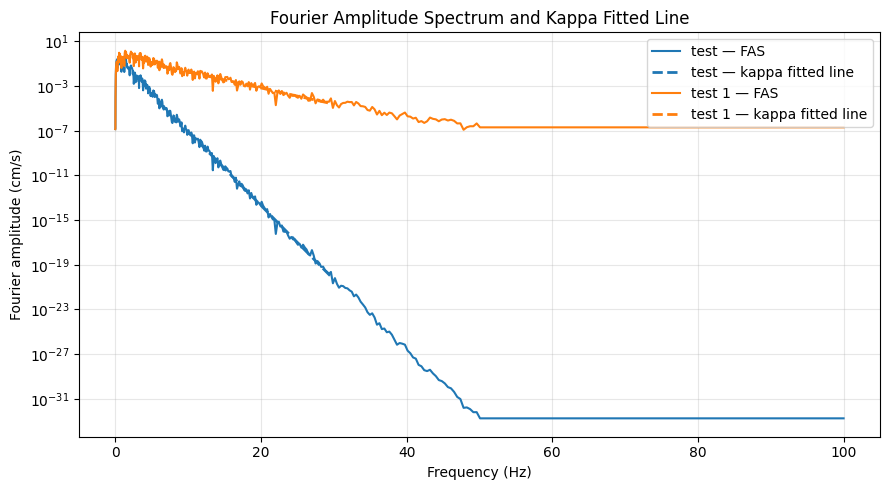

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

# Use the same color for each run in both DataFrames.
for color, column in zip(plt.rcParams["axes.prop_cycle"].by_key()["color"], FAS_df.columns):
    ax.plot(FAS_df.index, FAS_df[column], color=color, label=f"{column} — FAS")
    ax.plot(
        Kappa_Fitted_Line_df.index,
        Kappa_Fitted_Line_df[column],
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{column} — kappa fitted line",
    )

ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Fourier amplitude (cm/s)",
    title="Fourier Amplitude Spectrum and Kappa Fitted Line",
    yscale="log",
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()